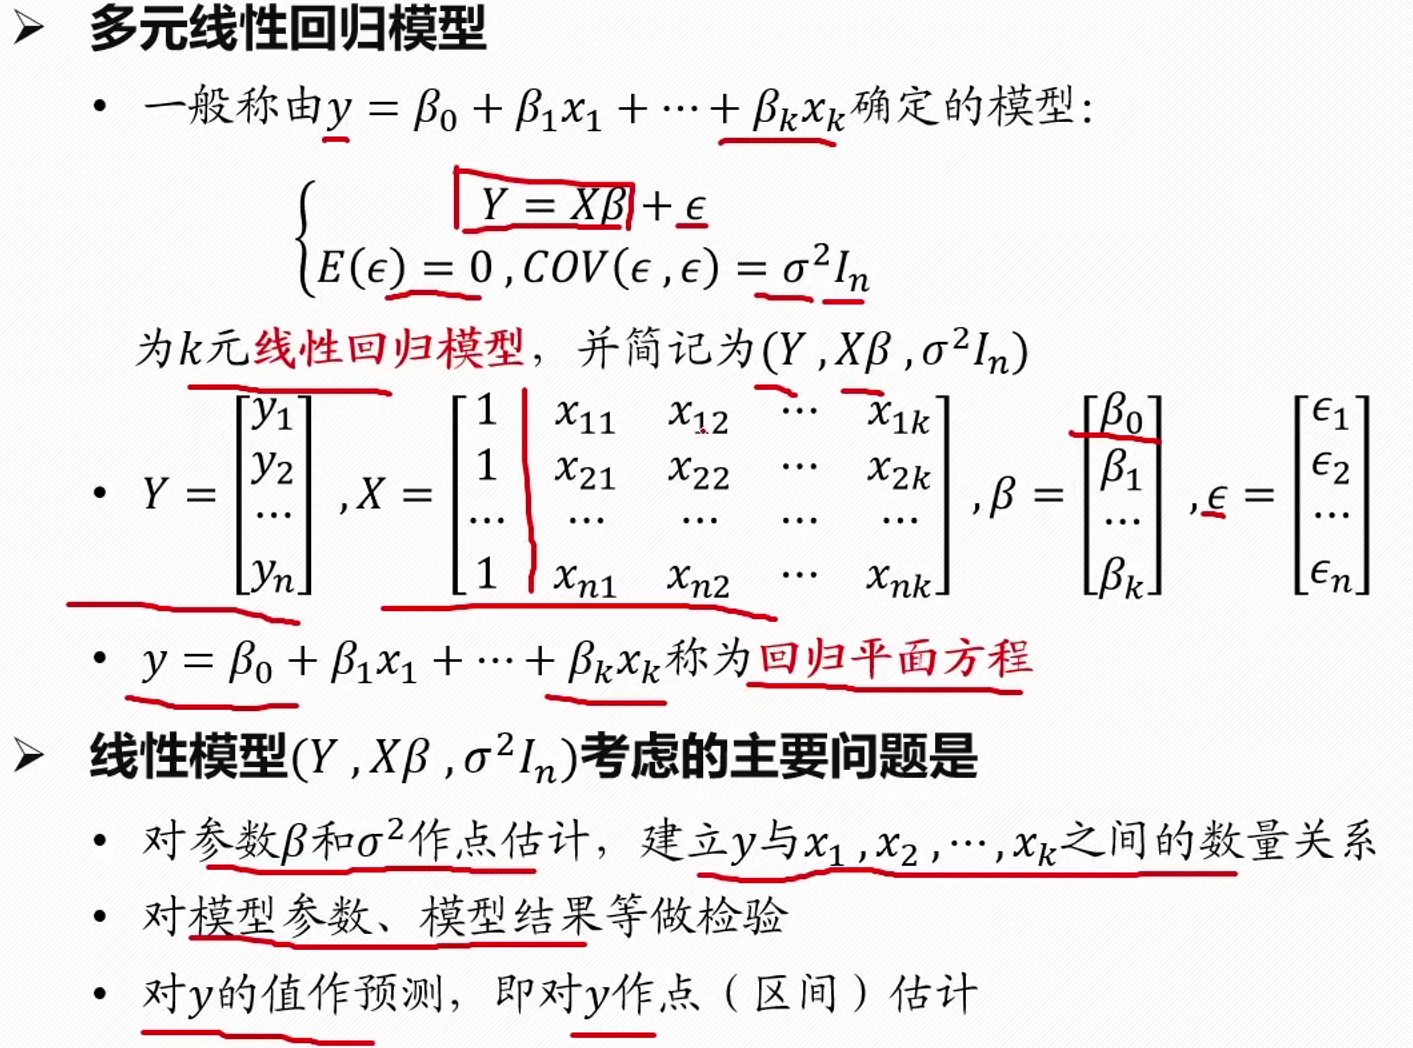

## 多元线性回归模型求解步骤：

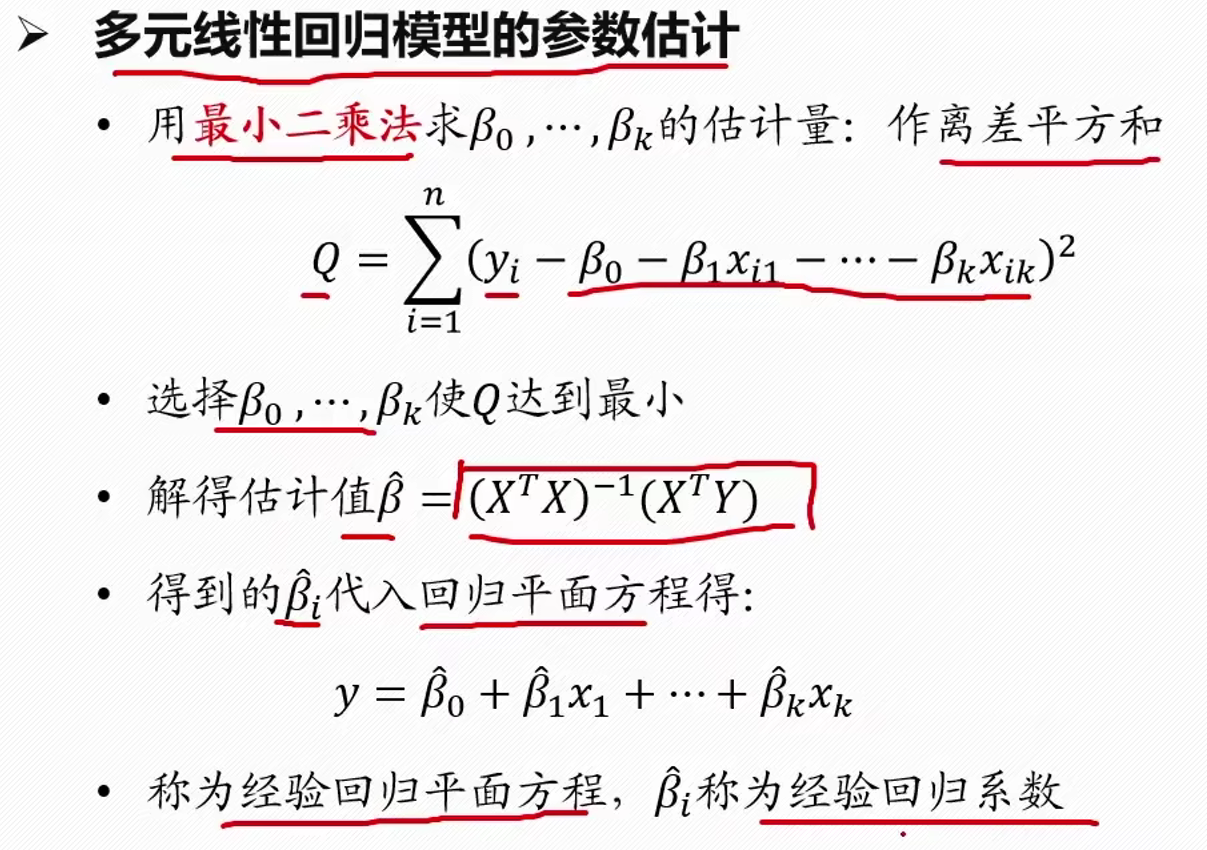

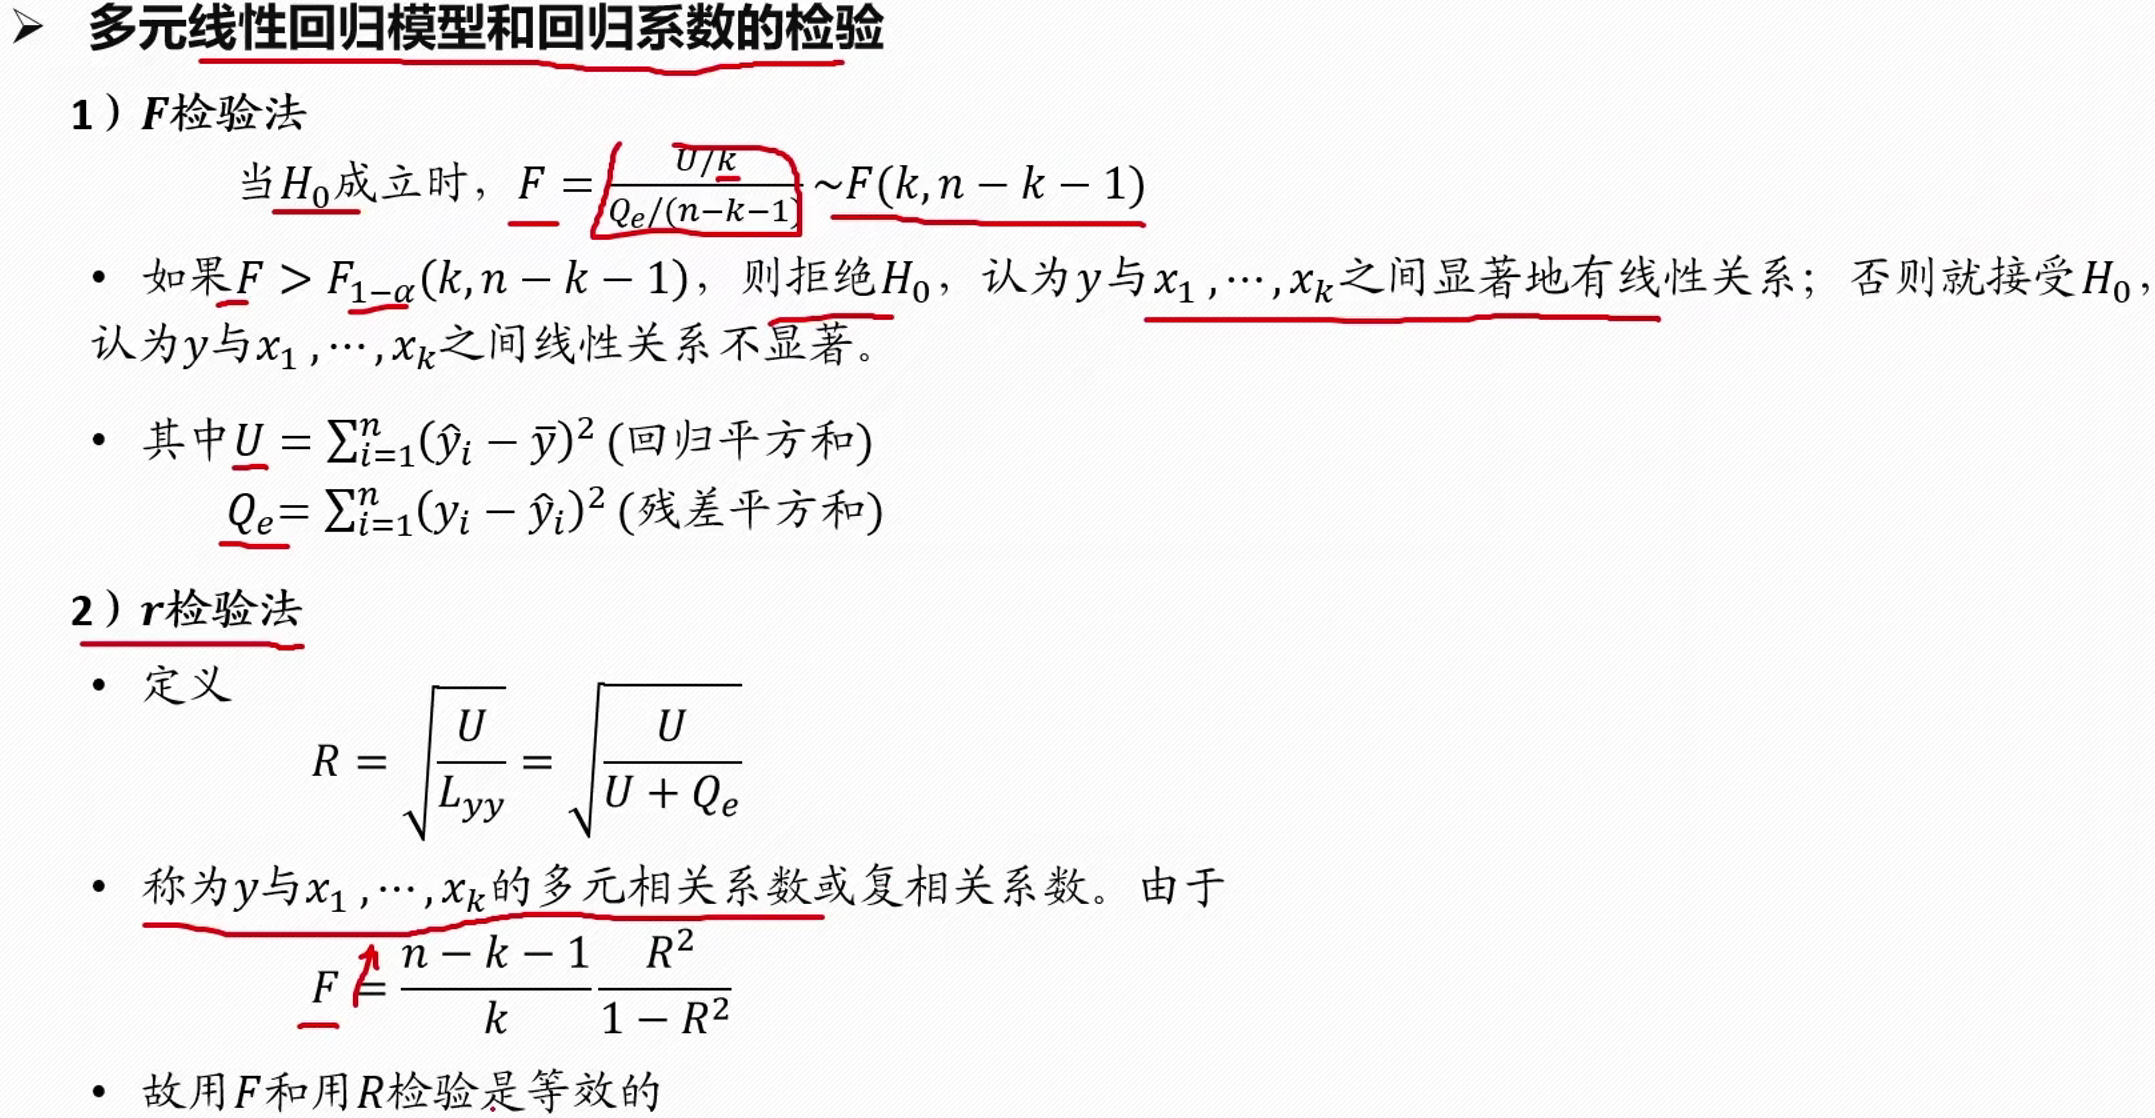

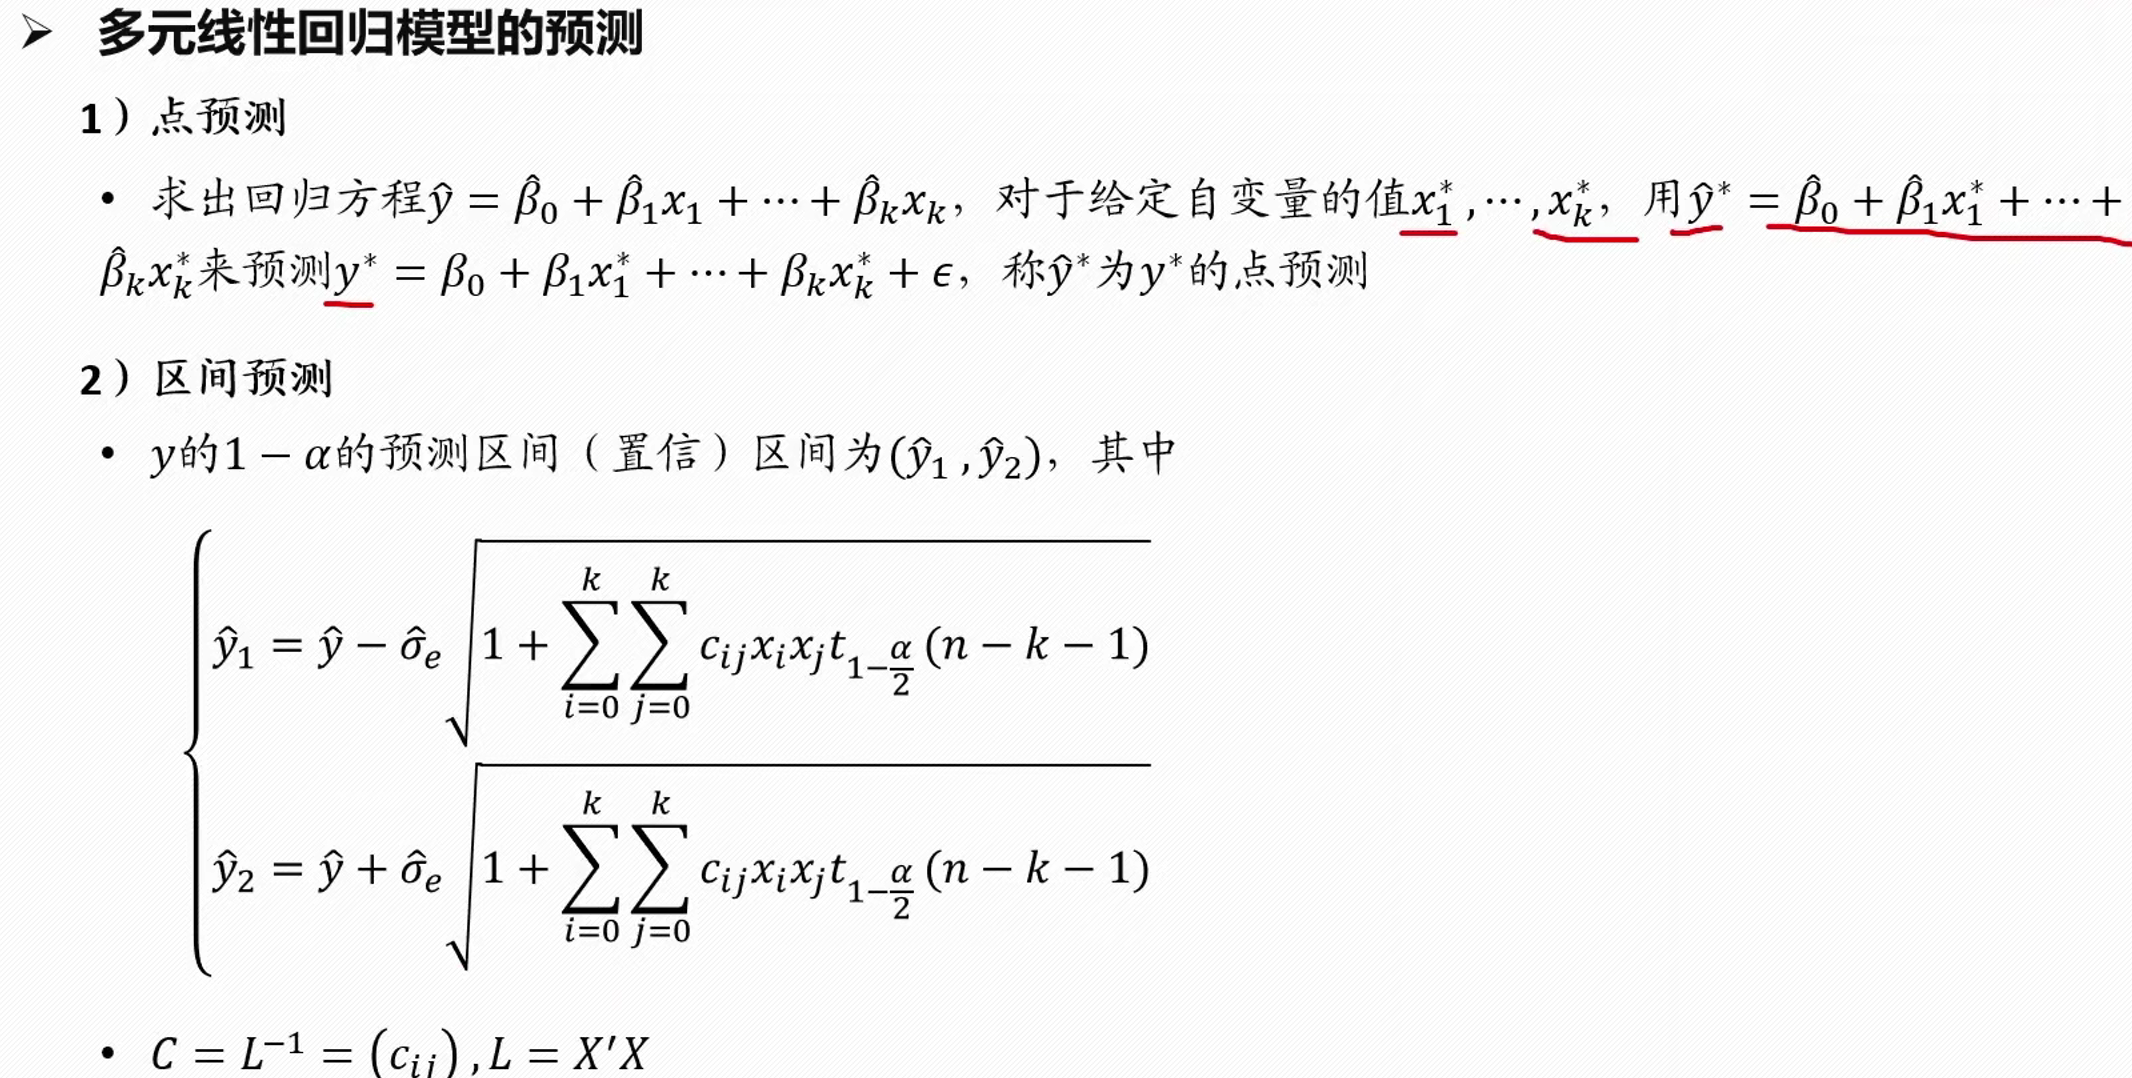

## 例题：

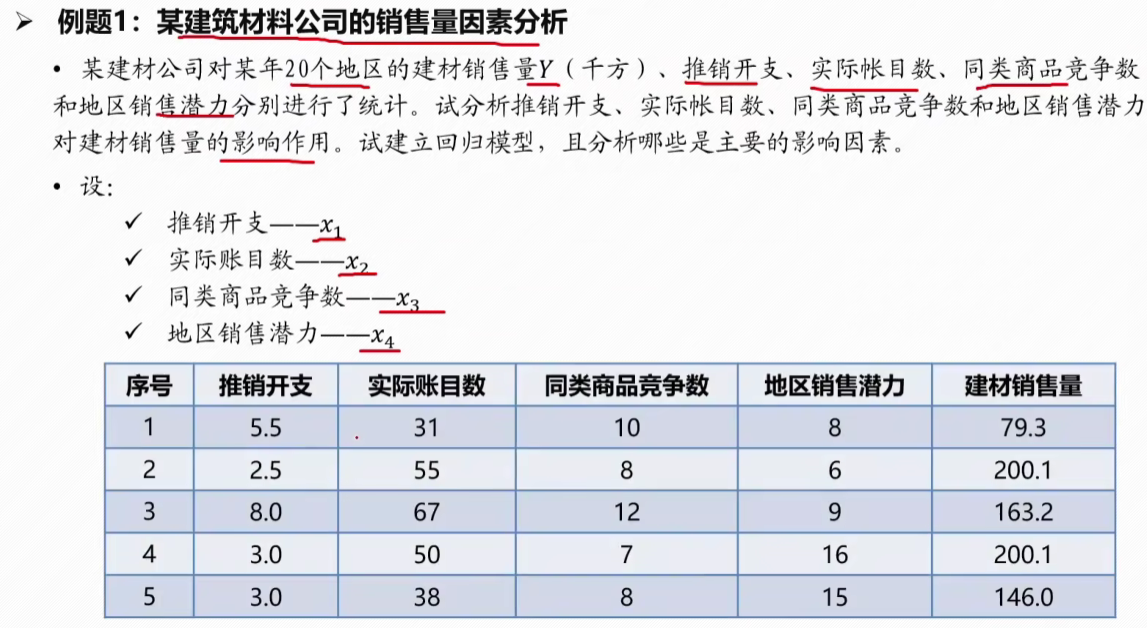

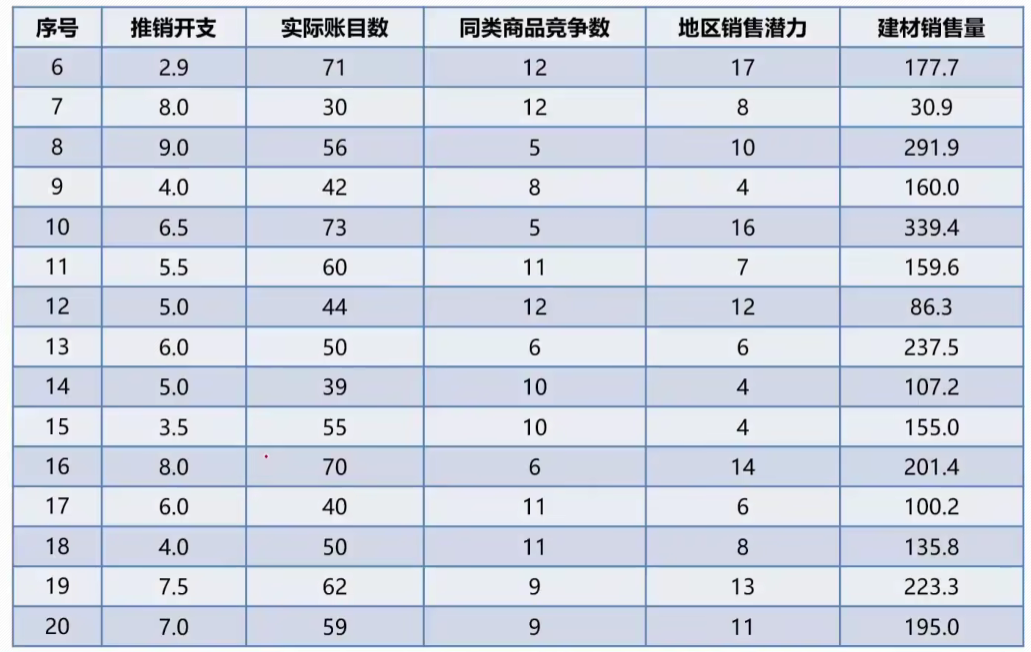

多元线性回归分析结果
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.878
Method:                 Least Squares   F-statistic:                     35.05
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           1.90e-07
Time:                        13:07:11   Log-Likelihood:                -90.189
No. Observations:                  20   AIC:                             190.4
Df Residuals:                      15   BIC:                             195.4
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        191.9158     41.666      4.6

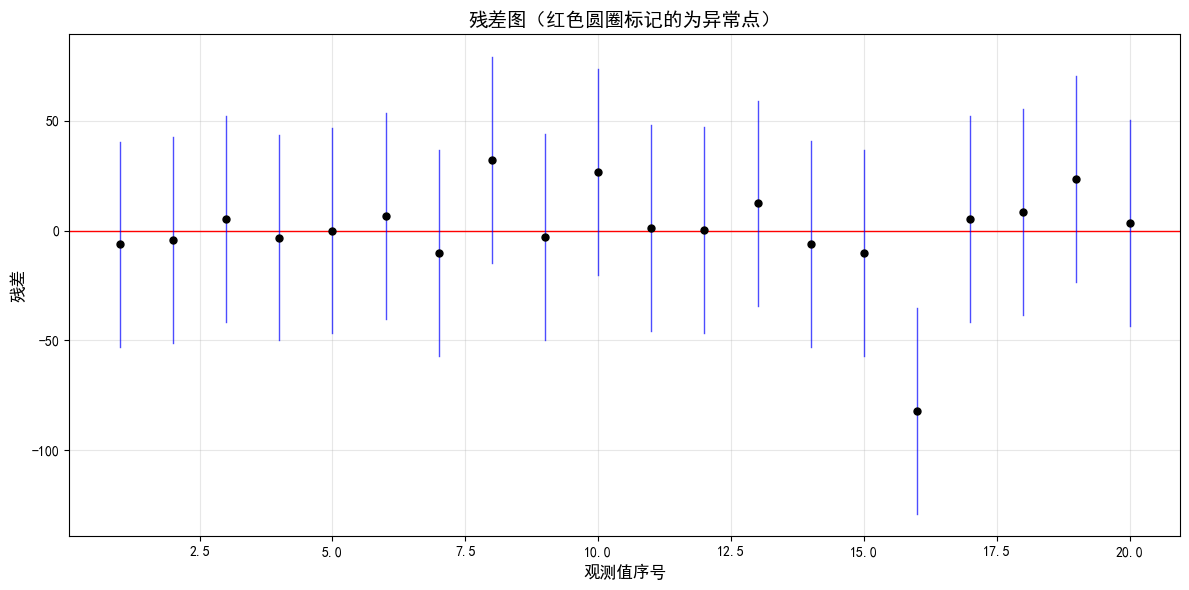


模型诊断信息

方差膨胀因子(VIF):
  Variable       VIF
0       x1  1.053975
1       x2  1.345821
2       x3  1.106960
3       x4  1.292495

Jarque-Bera正态性检验:
  统计量: 59.3960, p值: 0.0000

残差描述性统计:
  均值: -0.0000
  标准差: 21.9884
  最小值: -82.0245
  最大值: 32.1803


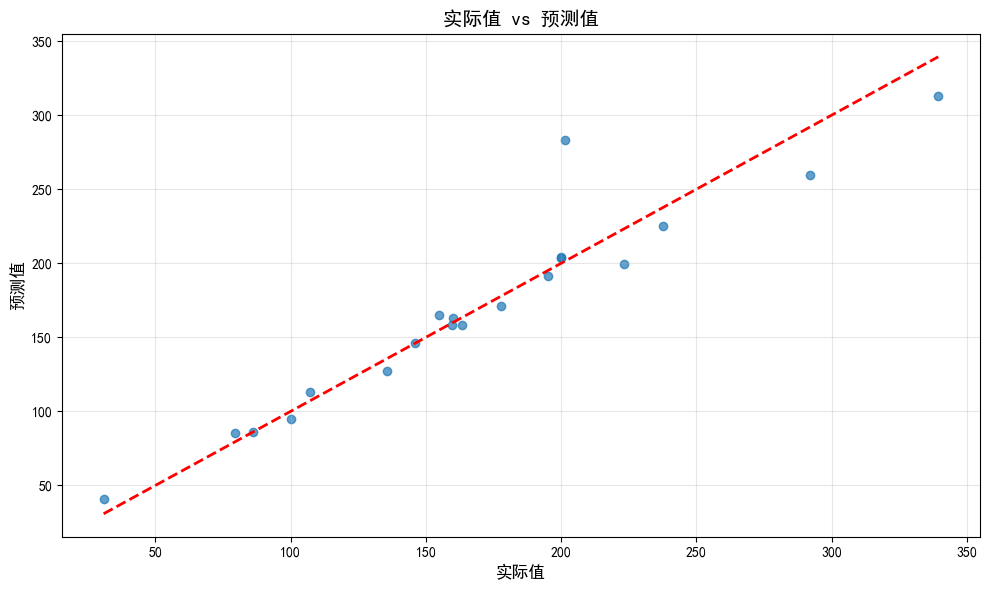

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.font_manager as fm

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1、某建筑材料公司的销售量因素分析
# （1）数据输入
x1 = np.array([5.5, 2.5, 8.0, 3.0, 3.0, 2.9, 8.0, 9.0, 4.0, 6.5, 5.5, 5.0, 6.0, 5.0, 3.5, 8.0, 6.0, 4.0, 7.5, 7.0])
x2 = np.array([31, 55, 67, 50, 38, 71, 30, 56, 42, 73, 60, 44, 50, 39, 55, 70, 40, 50, 62, 59])
x3 = np.array([10, 8, 12, 7, 8, 12, 12, 5, 8, 5, 11, 12, 6, 10, 10, 6, 11, 11, 9, 9])
x4 = np.array([8, 6, 9, 16, 15, 17, 8, 10, 4, 16, 7, 12, 6, 4, 4, 14, 6, 8, 13, 11])
y = np.array([79.3, 200.1, 163.2, 200.1, 146.0, 177.7, 30.9, 291.9, 160.0, 339.4, 159.6, 86.3, 237.5, 107.2, 155.0, 201.4, 100.2, 135.8, 223.3, 195.0])

# 构建自变量矩阵，包括常数项
X = sm.add_constant(np.column_stack((x1, x2, x3, x4)))

# （2）求结果 - 进行多元线性回归分析
model = sm.OLS(y, X)
results = model.fit()

# 输出回归结果
print("=" * 60)
print("多元线性回归分析结果")
print("=" * 60)
print(results.summary())

# 提取需要的统计量
b = results.params  # 系数
bint = results.conf_int()  # 置信区间
r = results.resid  # 残差
# 计算残差的置信区间
alpha = 0.05
n = len(y)
p = X.shape[1]  # 包括常数项
dof = n - p  # 自由度
t_val = stats.t.ppf(1 - alpha/2, dof)
r_std = np.std(r)
rint = np.column_stack((r - t_val * r_std, r + t_val * r_std))

# 输出系数和置信区间
print("\n系数 b:")
for i, (coef, name) in enumerate(zip(b, ['常数项', 'x1', 'x2', 'x3', 'x4'])):
    print(f"{name}: {coef:.6f}")

print("\n置信区间 bint:")
for i, ((lower, upper), name) in enumerate(zip(bint, ['常数项', 'x1', 'x2', 'x3', 'x4'])):
    print(f"{name}: [{lower:.6f}, {upper:.6f}]")

# 输出统计量
print(f"\nR²: {results.rsquared:.6f}")
print(f"调整R²: {results.rsquared_adj:.6f}")
print(f"F统计量: {results.fvalue:.6f}")
print(f"F检验的p值: {results.f_pvalue:.6e}")

# （3）画残差图 - 类似MATLAB的rcoplot
def rcoplot(r, rint):
    """绘制类似MATLAB的残差图"""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 绘制零线
    ax.axhline(y=0, color='r', linestyle='-', linewidth=1)
    
    # 绘制每个数据点的残差和置信区间
    for i in range(len(r)):
        ax.plot([i+1, i+1], [rint[i, 0], rint[i, 1]], 'b-', linewidth=1, alpha=0.7)
        ax.plot(i+1, r[i], 'ko', markersize=5)
    
    # 标记超出置信区间的点
    outliers = []
    for i in range(len(r)):
        if r[i] < rint[i, 0] or r[i] > rint[i, 1]:
            ax.plot(i+1, r[i], 'ro', markersize=7, markeredgewidth=2, 
                   markeredgecolor='red', markerfacecolor='none')
            outliers.append(i+1)
    
    ax.set_xlabel('观测值序号', fontsize=12)
    ax.set_ylabel('残差', fontsize=12)
    ax.set_title('残差图（红色圆圈标记的为异常点）', fontsize=14)
    ax.grid(True, alpha=0.3)
    
    if outliers:
        print(f"\n异常点检测: 第 {outliers} 个观测值可能为异常点")
    
    plt.tight_layout()
    plt.show()

# 绘制残差图
print("\n" + "=" * 60)
print("残差分析")
print("=" * 60)
rcoplot(r, rint)

# 额外的诊断信息
print("\n" + "=" * 60)
print("模型诊断信息")
print("=" * 60)

# 计算VIF（方差膨胀因子）来检查多重共线性
vif_data = pd.DataFrame()
vif_data["Variable"] = ['x1', 'x2', 'x3', 'x4']
vif_data["VIF"] = [variance_inflation_factor(X, i) for i in range(1, X.shape[1])]
print("\n方差膨胀因子(VIF):")
print(vif_data)

# 正态性检验
from scipy import stats as scipy_stats
jb_test = scipy_stats.jarque_bera(r)
print(f"\nJarque-Bera正态性检验:")
print(f"  统计量: {jb_test[0]:.4f}, p值: {jb_test[1]:.4f}")

# 残差描述性统计
print(f"\n残差描述性统计:")
print(f"  均值: {np.mean(r):.4f}")
print(f"  标准差: {np.std(r):.4f}")
print(f"  最小值: {np.min(r):.4f}")
print(f"  最大值: {np.max(r):.4f}")

# 预测值 vs 实际值图
plt.figure(figsize=(10, 6))
y_pred = results.predict(X)
plt.scatter(y, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('实际值', fontsize=12)
plt.ylabel('预测值', fontsize=12)
plt.title('实际值 vs 预测值', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

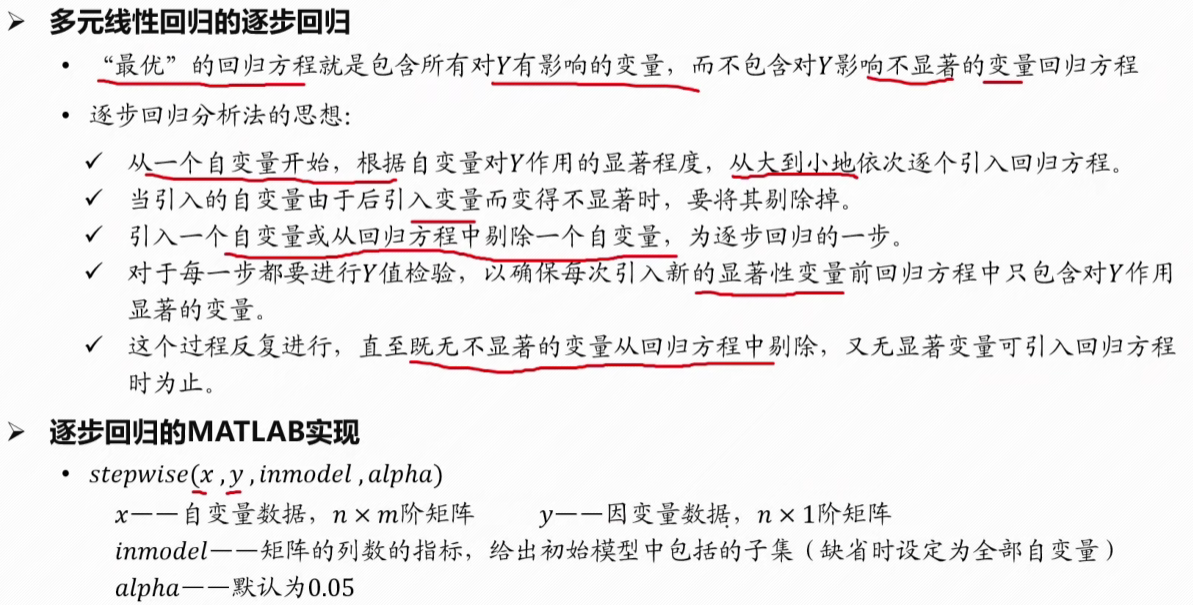

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm

# 设置中文字体（如果需要）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans', 'Arial Unicode MS', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1、水泥凝固时放热分析 - 数据输入
x1 = np.array([7, 1, 11, 11, 7, 11, 3, 1, 2, 21, 1, 11, 10])
x2 = np.array([26, 29, 56, 31, 52, 55, 71, 31, 54, 47, 40, 66, 68])
x3 = np.array([6, 15, 8, 8, 6, 9, 17, 22, 18, 4, 23, 9, 8])
x4 = np.array([60, 52, 20, 47, 33, 22, 6, 44, 22, 26, 34, 12, 12])
y = np.array([78.5, 74.3, 104.3, 87.6, 95.9, 109.2, 102.7, 72.5, 93.1, 115.9, 83.8, 113.3, 109.4])

print("=" * 50)
print("水泥凝固时放热分析数据")
print("=" * 50)
print(f"x1: {x1}")
print(f"x2: {x2}")
print(f"x3: {x3}")
print(f"x4: {x4}")
print(f"y:  {y}")

# 2、逐步回归分析（使用statsmodels进行变量选择）
print("\n" + "=" * 50)
print("逐步回归分析（使用所有变量）")
print("=" * 50)

# 使用所有变量进行回归分析
X_all = np.column_stack((x1, x2, x3, x4))
X_all = sm.add_constant(X_all)  # 添加常数项
model_all = sm.OLS(y, X_all)
results_all = model_all.fit()
print(results_all.summary())

# 3、线性回归（选择x1和x2作为自变量）
print("\n" + "=" * 50)
print("线性回归（使用x1和x2）")
print("=" * 50)

# (3) 线性回归
X_selected = np.column_stack((np.ones(13), x1, x2))  # 添加常数项

# 使用statsmodels进行详细回归分析
model_sm = sm.OLS(y, X_selected)
results_sm = model_sm.fit()
print(results_sm.summary())


# 使用sklearn获取系数
model_sklearn = LinearRegression()
model_sklearn.fit(X_selected[:, 1:], y)  # 拟合模型，排除常数项列
b = np.concatenate(([model_sklearn.intercept_], model_sklearn.coef_))  # 获取系数

print(f"\n回归系数 b: {b}")
print(f"回归方程: y = {b[0]:.4f} + {b[1]:.4f}*x1 + {b[2]:.4f}*x2")

# 4、作图 - 三维图形可视化
print("\n" + "=" * 50)
print("三维图形可视化")
print("=" * 50)

# 定义自变量的范围
x1_range = np.arange(-10, 10.1, 0.1)  # x1的取值范围
x2_range = np.arange(-10, 10.1, 0.1)  # x2的取值范围

# 计算对应的因变量值
X1, X2 = np.meshgrid(x1_range, x2_range)  # 创建网格点坐标矩阵
Z = b[0] + b[1] * X1 + b[2] * X2  # 使用实际计算出的系数

# 绘制三维图形
fig = plt.figure(figsize=(15, 10))

# 第一个子图：三维曲面图
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8, edgecolor='none')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_zlabel('z')
ax1.set_title(f'Z = {b[0]:.4f} + {b[1]:.4f}*X1 + {b[2]:.4f}*X2')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=5)

# 第二个子图：散点图与回归平面
ax2 = fig.add_subplot(122, projection='3d')
# 绘制回归平面
ax2.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.3)
# 绘制实际数据点
ax2.scatter(x1, x2, y, color='red', s=50, label='实际数据点')
ax2.set_xlabel('x1')
ax2.set_ylabel('x2')
ax2.set_zlabel('y')
ax2.set_title('实际数据点与回归平面')
ax2.legend()

plt.tight_layout()
plt.show()

# 5、预测和残差分析
print("\n" + "=" * 50)
print("预测结果和残差分析")
print("=" * 50)

# 计算预测值
y_pred = model_sklearn.predict(X_selected[:, 1:])

# 计算残差
residuals = y - y_pred

# 输出预测结果
print("\n预测结果对比:")
print("序号  实际值    预测值    残差")
print("-" * 40)
for i in range(len(y)):
    print(f"{i+1:2d}   {y[i]:6.1f}   {y_pred[i]:6.1f}   {residuals[i]:6.2f}")

print(f"\n残差统计:")
print(f"平均残差: {np.mean(residuals):.4f}")
print(f"残差标准差: {np.std(residuals):.4f}")
print(f"最大残差: {np.max(np.abs(residuals)):.4f}")

# 6、绘制残差图
plt.figure(figsize=(12, 5))

# 残差散点图
plt.subplot(121)
plt.scatter(range(1, len(residuals)+1), residuals, color='blue', s=50)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('观测序号')
plt.ylabel('残差')
plt.title('残差图')
plt.grid(True, alpha=0.3)

# 预测值 vs 实际值图
plt.subplot(122)
plt.scatter(y, y_pred, color='green', s=50)
plt.plot([min(y), max(y)], [min(y), max(y)], 'r--')
plt.xlabel('实际值')
plt.ylabel('预测值')
plt.title('实际值 vs 预测值')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n分析完成！")

水泥凝固时放热分析数据
x1: [ 7  1 11 11  7 11  3  1  2 21  1 11 10]
x2: [26 29 56 31 52 55 71 31 54 47 40 66 68]
x3: [ 6 15  8  8  6  9 17 22 18  4 23  9  8]
x4: [60 52 20 47 33 22  6 44 22 26 34 12 12]
y:  [ 78.5  74.3 104.3  87.6  95.9 109.2 102.7  72.5  93.1 115.9  83.8 113.3
 109.4]

逐步回归分析（使用所有变量）
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     111.5
Date:                Thu, 28 Aug 2025   Prob (F-statistic):           4.76e-07
Time:                        13:33:09   Log-Likelihood:                -26.918
No. Observations:                  13   AIC:                             63.84
Df Residuals:                       8   BIC:                             66.66
Df Model:                           4                                      